In [61]:
from google.colab import files

uploaded = files.upload()

Saving test_fe.csv to test_fe (2).csv
Saving train_fe.csv to train_fe (2).csv


In [62]:
from google.colab import files

uploaded = files.upload()

Saving sample_submission.csv to sample_submission (1).csv


In [63]:
!pip install -q xgboost

In [64]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score

from xgboost import XGBClassifier

In [65]:
import torch

print(
    "CUDA Available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

CUDA Available: True
GPU: Tesla T4


In [66]:
train = pd.read_csv("train_fe.csv")
test = pd.read_csv("test_fe.csv")

sample_submission = pd.read_csv(
    "sample_submission.csv"
)

print(train.shape)
print(test.shape)

(577347, 19)
(247435, 18)


In [67]:
for df in [train, test]:

    # radians

    df["alpha_rad"] = np.radians(
        df["alpha"]
    )

    df["delta_rad"] = np.radians(
        df["delta"]
    )

    # sky coordinates

    df["x_coord"] = (
        np.cos(df["delta_rad"])
        * np.cos(df["alpha_rad"])
    )

    df["y_coord"] = (
        np.cos(df["delta_rad"])
        * np.sin(df["alpha_rad"])
    )

    df["z_coord"] = np.sin(
        df["delta_rad"]
    )

    # ratios

    df["u_div_g"] = (
        df["u"] /
        (df["g"] + 1e-6)
    )

    df["g_div_r"] = (
        df["g"] /
        (df["r"] + 1e-6)
    )

    df["r_div_i"] = (
        df["r"] /
        (df["i"] + 1e-6)
    )

    df["i_div_z"] = (
        df["i"] /
        (df["z"] + 1e-6)
    )

    # redshift features

    df["redshift_sq"] = (
        df["redshift"] ** 2
    )

    df["redshift_cube"] = (
        df["redshift"] ** 3
    )

print("Feature Engineering Done")

Feature Engineering Done


In [68]:
for col in [
    "spectral_type",
    "galaxy_population"
]:

    le_col = LabelEncoder()

    combined = pd.concat([
        train[col],
        test[col]
    ])

    le_col.fit(combined)

    train[col] = le_col.transform(
        train[col]
    )

    test[col] = le_col.transform(
        test[col]
    )

In [69]:
TARGET = "class"

X = train.drop(
    columns=["id", TARGET]
)

X_test = test.drop(
    columns=["id"]
)

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    train[TARGET]
)

print(X.shape)

(577347, 28)


In [70]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_preds = np.zeros(len(train))

test_probs = np.zeros(
    (
        len(test),
        len(target_encoder.classes_)
    )
)

cv_scores = []

In [71]:
for fold, (
    train_idx,
    valid_idx
) in enumerate(
    skf.split(X, y)
):

    print(
        f"\n===== Fold {fold+1} ====="
    )

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y[train_idx]
    y_valid = y[valid_idx]

    model = XGBClassifier(

        objective="multi:softprob",

        num_class=3,

        n_estimators=2500,

        learning_rate=0.03,

        max_depth=8,

        subsample=0.8,

        colsample_bytree=0.8,

        min_child_weight=3,

        reg_alpha=0.1,

        reg_lambda=1.0,

        random_state=42,

        tree_method="hist",

        device="cuda",

        eval_metric="mlogloss"
    )

    model.fit(
        X_train,
        y_train
    )

    valid_pred = model.predict(
        X_valid
    )

    score = balanced_accuracy_score(
        y_valid,
        valid_pred
    )

    cv_scores.append(score)

    print(
        "Fold Score:",
        score
    )

    oof_preds[
        valid_idx
    ] = valid_pred

    test_probs += (
        model.predict_proba(X_test)
        / skf.n_splits
    )


===== Fold 1 =====
Fold Score: 0.9568036291217649

===== Fold 2 =====
Fold Score: 0.9580113842853892

===== Fold 3 =====
Fold Score: 0.9568889645984404

===== Fold 4 =====
Fold Score: 0.9567968441103606

===== Fold 5 =====
Fold Score: 0.9581244549079315


In [72]:
print(
    "Mean CV:",
    np.mean(cv_scores)
)

print(
    "Std CV:",
    np.std(cv_scores)
)

Mean CV: 0.9573250554047773
Std CV: 0.0006084660433487379


In [73]:
cv_df = pd.DataFrame({

    "fold":
        range(
            1,
            len(cv_scores)+1
        ),

    "score":
        cv_scores

})

cv_df.to_csv(
    "xgb_cv_scores.csv",
    index=False
)

cv_df

,fold,score
0,1,0.956804
1,2,0.958011
2,3,0.956889
3,4,0.956797
4,5,0.958124


In [74]:
feature_importance = pd.DataFrame({

    "feature":
        X.columns,

    "importance":
        model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(30)

,feature,importance
7,redshift,0.212395
15,griz,0.182258
26,redshift_sq,0.134853
16,redshift_log,0.128153
14,ugri,0.076386
3,g,0.030713
27,redshift_cube,0.027005
6,z,0.022465
23,g_div_r,0.022231
5,i,0.013011


In [75]:
feature_importance.to_csv(
    "xgb_feature_importance.csv",
    index=False
)

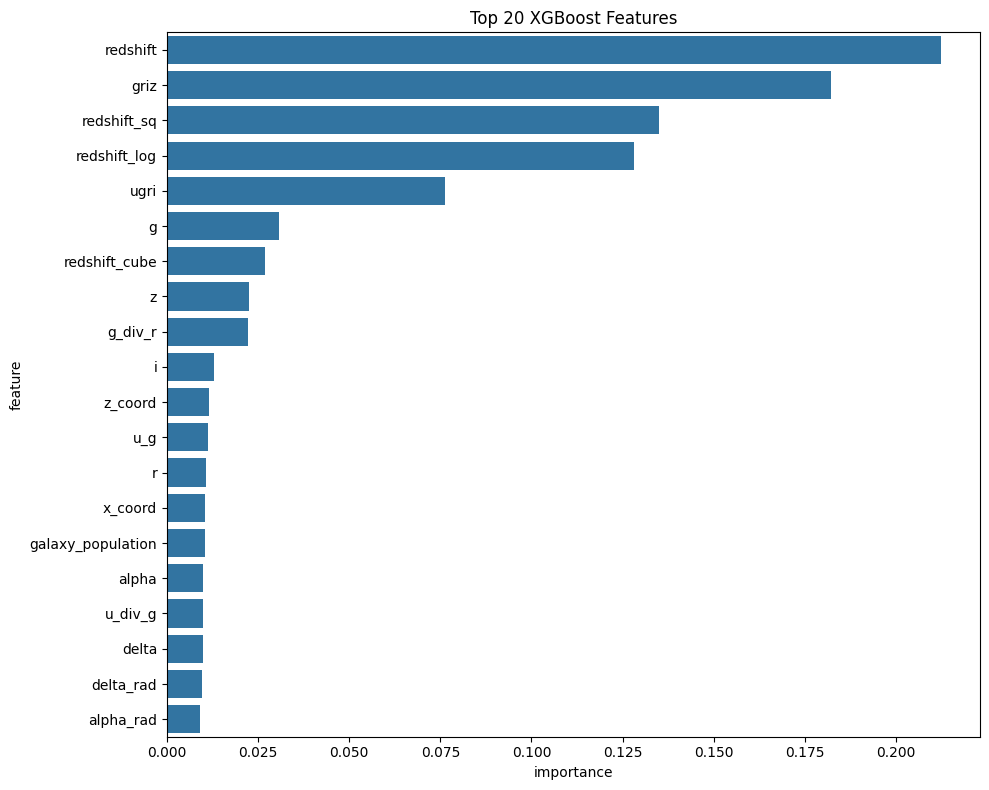

In [76]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="importance",
    y="feature"
)

plt.title(
    "Top 20 XGBoost Features"
)

plt.tight_layout()

plt.savefig(
    "xgb_feature_importance.png",
    dpi=300
)

plt.show()

In [77]:
preds = np.argmax(
    test_probs,
    axis=1
)

submission = pd.DataFrame({

    "id":
        test["id"],

    "class":
        target_encoder.inverse_transform(
            preds
        )
})

submission.to_csv(
    "submission_xgb.csv",
    index=False
)

submission.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [78]:
prob_df = pd.DataFrame(
    test_probs,
    columns=target_encoder.classes_
)

prob_df.insert(
    0,
    "id",
    test["id"]
)

prob_df.to_csv(
    "xgb_prob.csv",
    index=False
)

In [79]:
from google.colab import files

files.download(
    "submission_xgb.csv"
)

files.download(
    "xgb_prob.csv"
)

files.download(
    "xgb_feature_importance.csv"
)

files.download(
    "xgb_cv_scores.csv"
)

files.download(
    "xgb_feature_importance.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>